In [50]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', size=14)
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn import metrics
import statsmodels.stats.api as sms
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
from sklearn.naive_bayes import GaussianNB

In [51]:
df = pd.read_csv('pima-indians-diabetes.csv')

In [52]:
data = df.copy()

In [53]:
data.head()

,Preg,Plas,Pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [54]:
data.rename(columns = {'Preg':'Pregnancy',
                       'Plas':'Glucose',
                       'Pres':'BloodPressure',
                       'skin':'SkinThickness',
                       'test':'Insulin',
                       'mass':'BMI',
                       'pedi':'Pedigree',
                       'age':'Age',
                       'class':'Class'}, inplace=True)

In [55]:
data.isna().sum()

Pregnancy        0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
Pedigree         0
Age              0
Class            0
dtype: int64

In [56]:
data.isnull().sum()

Pregnancy        0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
Pedigree         0
Age              0
Class            0
dtype: int64

In [57]:
data.isin([0]).sum()

Pregnancy        111
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
Pedigree           0
Age                0
Class            500
dtype: int64

In [58]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
data[cols] = data[cols].replace(0, np.nan)
data[cols] = data[cols].fillna(data[cols].mean())
data.isna().sum()

Pregnancy        0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
Pedigree         0
Age              0
Class            0
dtype: int64

### Bivariate analysis

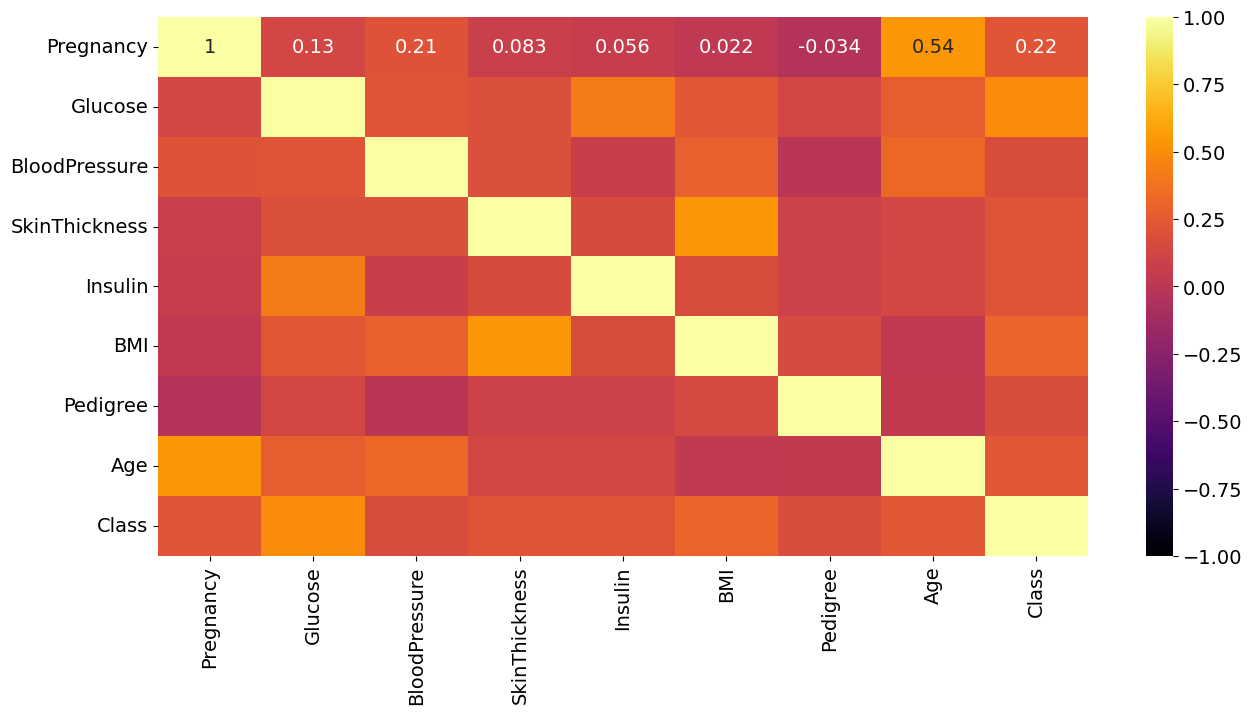

In [59]:
plt.figure(figsize=(15,7))
sns.heatmap(data.corr(), annot=True, vmin=-1, vmax=1, cmap='inferno')
plt.show();

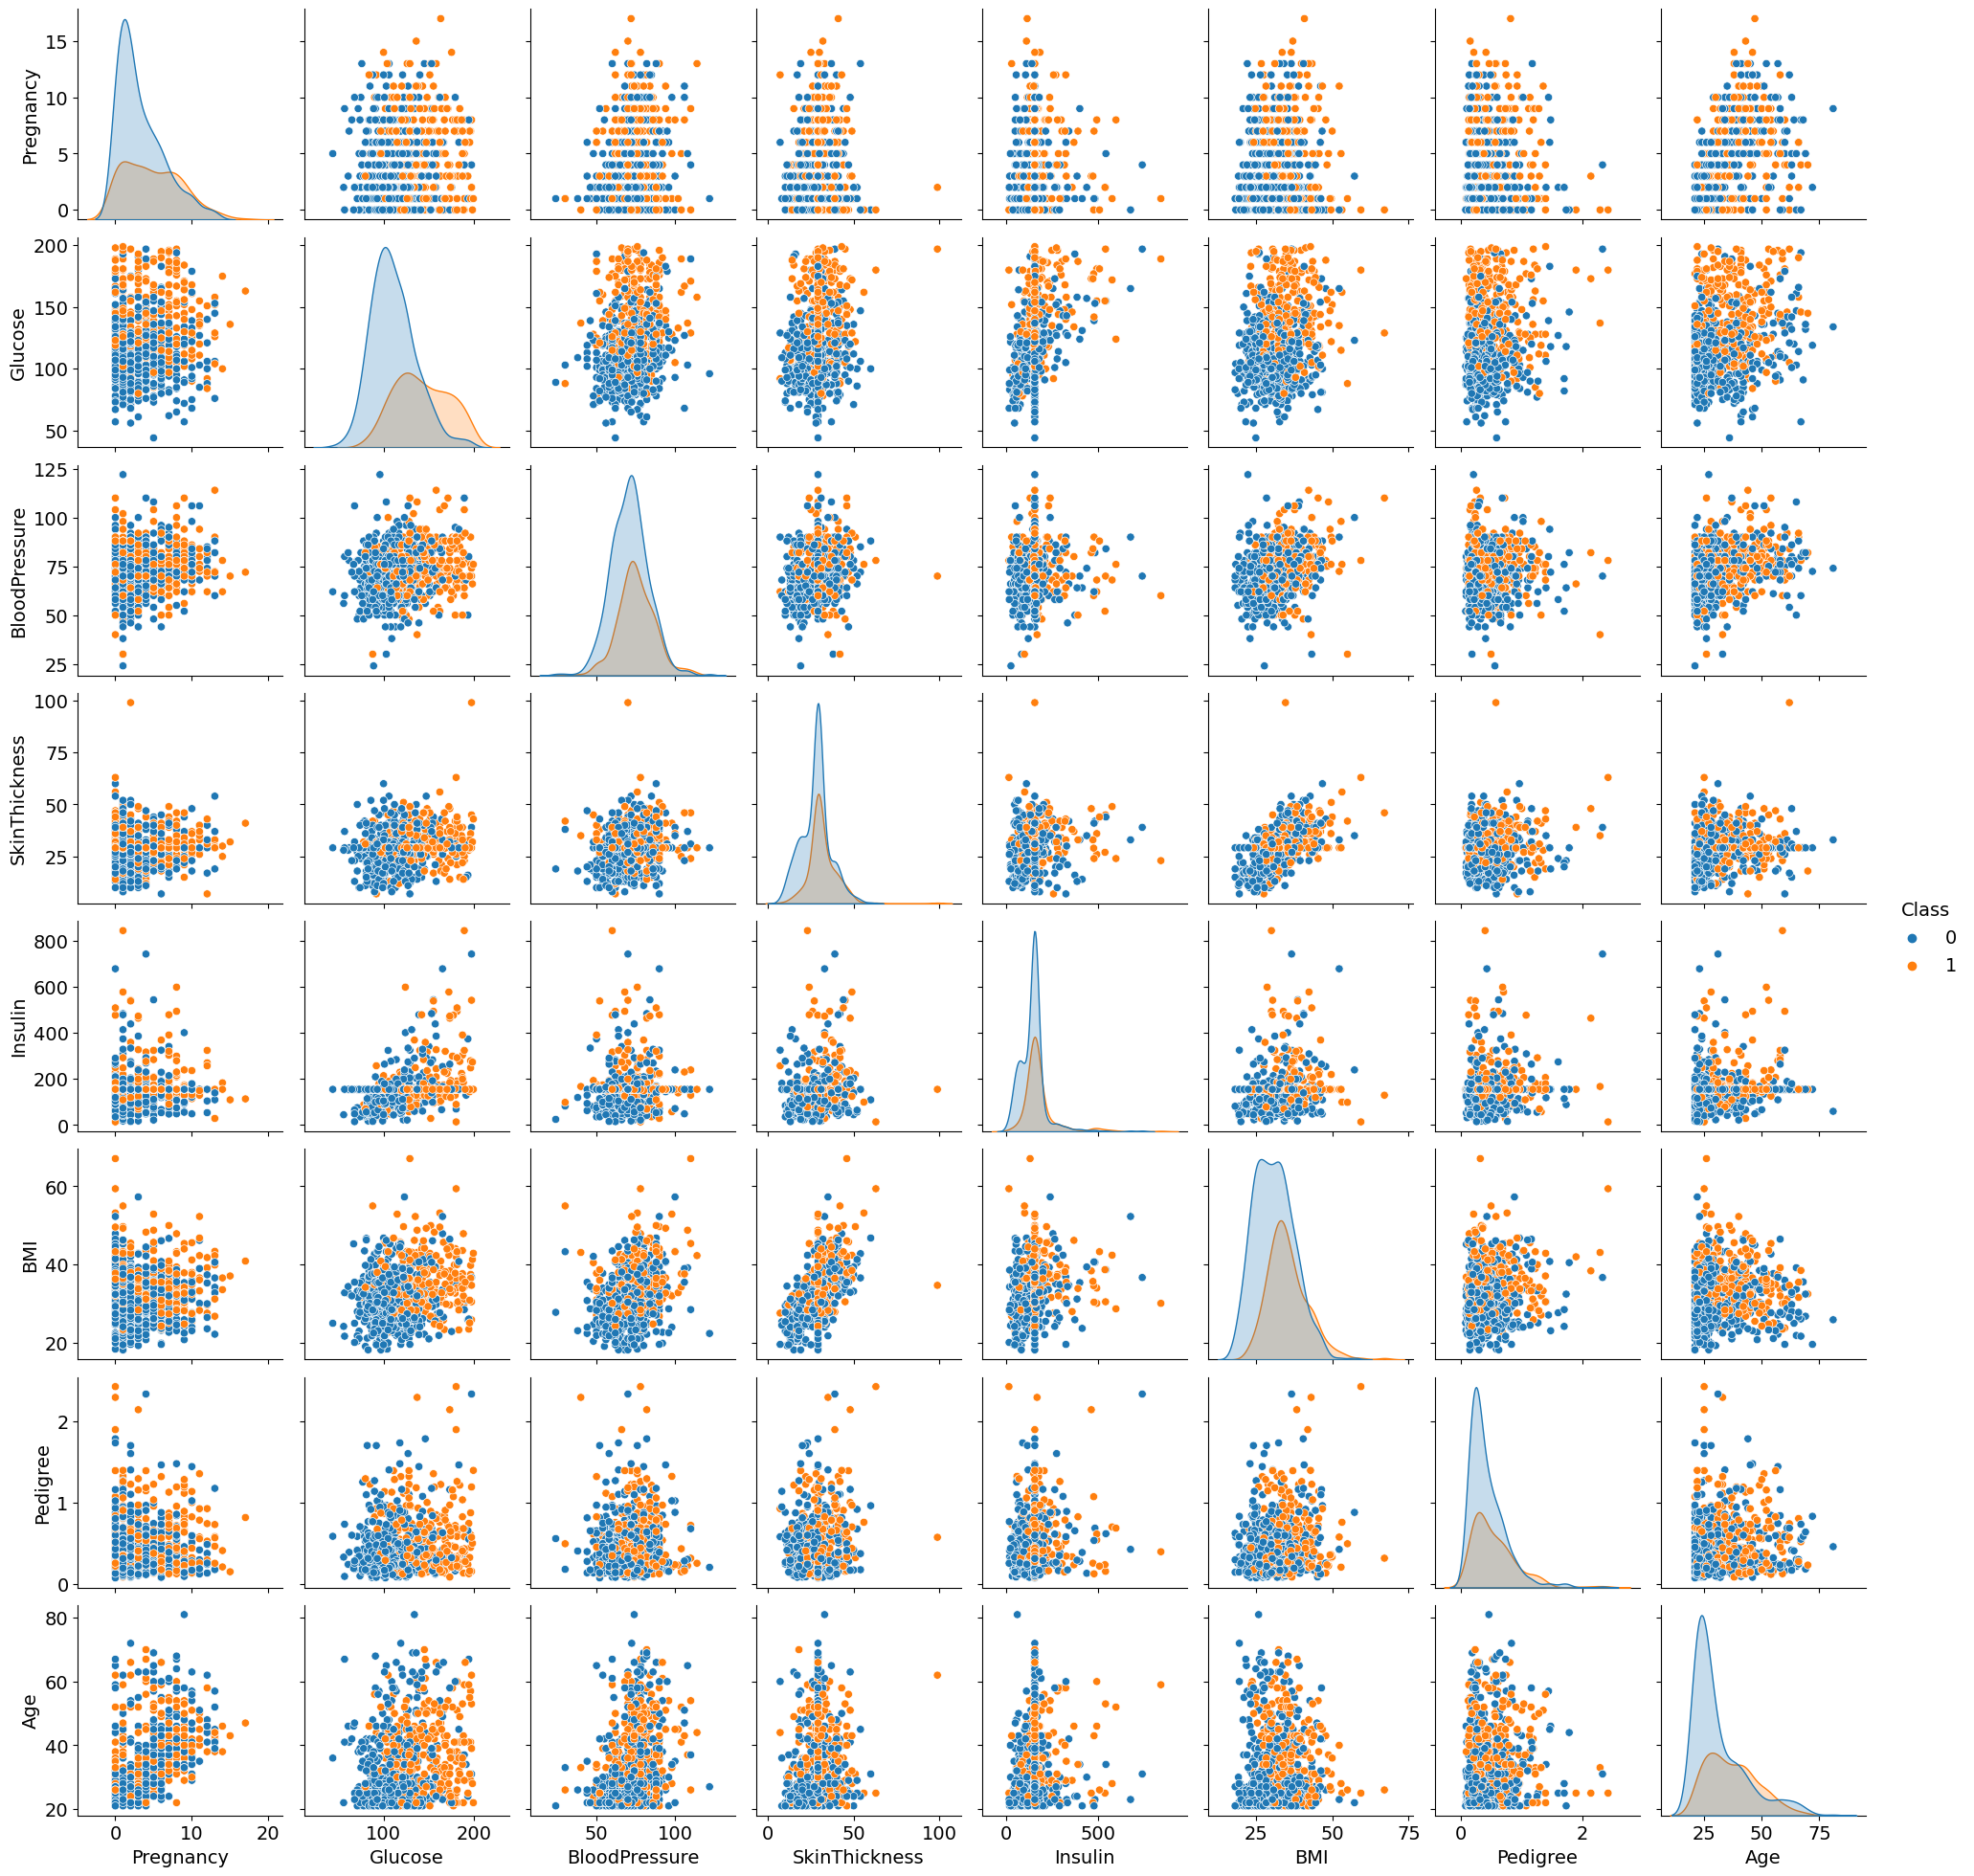

In [60]:
sns.pairplot(data, hue='Class')
plt.show();

In [61]:
round(data['Class'].value_counts(1)*100,2)

Class
0    65.1
1    34.9
Name: proportion, dtype: float64

In [62]:
x = data.drop(['Class'], axis=1)
y = data['Class']
x = add_constant(x)
x = pd.get_dummies(x, drop_first=True)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, stratify = y, random_state = 1)

In [63]:
lg = sm.Logit(y_train, x_train.astype(float)).fit()

Optimization terminated successfully.
         Current function value: 0.449508
         Iterations 6


In [64]:
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:                  537
Model:                          Logit   Df Residuals:                      528
Method:                           MLE   Df Model:                            8
Date:                Sat, 19 Apr 2025   Pseudo R-squ.:                  0.3045
Time:                        08:19:25   Log-Likelihood:                -241.39
converged:                       True   LL-Null:                       -347.09
Covariance Type:            nonrobust   LLR p-value:                 2.518e-41
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -9.7226      1.021     -9.522      0.000     -11.724      -7.721
Pregnancy         0.1445      0.039      3.706      0.000       0.068       0.221
Glucose           0.0363      0.005     

In [65]:
pred_train = np.round(lg.predict(x_train)>0.5)

In [66]:
confusion_matrix(y_train, pred_train)

array([[308,  42],
       [ 73, 114]], dtype=int64)

In [67]:
accuracy_score(y_train, pred_train)

0.7858472998137802

In [68]:
vif_series = pd.Series([variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])],
                       index=x_train.columns,
                       dtype=float)
vif_series

const            55.156267
Pregnancy         1.418041
Glucose           1.358583
BloodPressure     1.226593
SkinThickness     1.446856
Insulin           1.227806
BMI               1.546783
Pedigree          1.054447
Age               1.637294
dtype: float64

In [69]:
x_train1 = x_train.drop(['SkinThickness'], axis=1)

In [70]:
lg1 = sm.Logit(y_train, x_train1.astype(float)).fit()
pred_train1 = np.round(lg1.predict(x_train1))

Optimization terminated successfully.
         Current function value: 0.449511
         Iterations 6


In [71]:
print(lg1.summary())

                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:                  537
Model:                          Logit   Df Residuals:                      529
Method:                           MLE   Df Model:                            7
Date:                Sat, 19 Apr 2025   Pseudo R-squ.:                  0.3045
Time:                        08:19:25   Log-Likelihood:                -241.39
converged:                       True   LL-Null:                       -347.09
Covariance Type:            nonrobust   LLR p-value:                 4.406e-42
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -9.7189      1.018     -9.548      0.000     -11.714      -7.724
Pregnancy         0.1446      0.039      3.707      0.000       0.068       0.221
Glucose           0.0363      0.005     

In [72]:
x_train2 = x_train1.drop(['BloodPressure'], axis=1)

In [73]:
lg2 = sm.Logit(y_train, x_train2.astype(float)).fit()
pred_train2 = np.round(lg2.predict(x_train2))

Optimization terminated successfully.
         Current function value: 0.449630
         Iterations 6


In [74]:
print(lg2.summary())

                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:                  537
Model:                          Logit   Df Residuals:                      530
Method:                           MLE   Df Model:                            6
Date:                Sat, 19 Apr 2025   Pseudo R-squ.:                  0.3043
Time:                        08:19:25   Log-Likelihood:                -241.45
converged:                       True   LL-Null:                       -347.09
Covariance Type:            nonrobust   LLR p-value:                 7.548e-43
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -9.8778      0.919    -10.744      0.000     -11.680      -8.076
Pregnancy      0.1442      0.039      3.702      0.000       0.068       0.220
Glucose        0.0361      0.005      7.837      0.0

In [75]:
x_train3 = x_train2.drop(['Insulin'], axis=1)

In [76]:
lg3 = sm.Logit(y_train, x_train3.astype(float)).fit()
pred_train3 = np.around(lg3.predict(x_train3))

Optimization terminated successfully.
         Current function value: 0.450056
         Iterations 6


In [77]:
print(lg3.summary())

                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:                  537
Model:                          Logit   Df Residuals:                      531
Method:                           MLE   Df Model:                            5
Date:                Sat, 19 Apr 2025   Pseudo R-squ.:                  0.3037
Time:                        08:19:25   Log-Likelihood:                -241.68
converged:                       True   LL-Null:                       -347.09
Covariance Type:            nonrobust   LLR p-value:                 1.378e-43
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -9.8936      0.921    -10.746      0.000     -11.698      -8.089
Pregnancy      0.1440      0.039      3.686      0.000       0.067       0.221
Glucose        0.0372      0.004      8.584      0.0

In [78]:
x_train4 = x_train3.drop(['Age'], axis=1)

In [79]:
lg4 = sm.Logit(y_train, x_train4.astype(float)).fit()
pred_train4 = np.round(lg4.predict(x_train4))

Optimization terminated successfully.
         Current function value: 0.451011
         Iterations 6


In [80]:
print(lg4.summary())

                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:                  537
Model:                          Logit   Df Residuals:                      532
Method:                           MLE   Df Model:                            4
Date:                Sat, 19 Apr 2025   Pseudo R-squ.:                  0.3022
Time:                        08:19:25   Log-Likelihood:                -242.19
converged:                       True   LL-Null:                       -347.09
Covariance Type:            nonrobust   LLR p-value:                 2.951e-44
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -9.6760      0.890    -10.873      0.000     -11.420      -7.932
Pregnancy      0.1645      0.034      4.881      0.000       0.098       0.231
Glucose        0.0381      0.004      8.943      0.0

In [81]:
odds = np.exp(lg4.params)
pd.DataFrame(odds, x_train4.columns, columns=['odds']).T

,const,Pregnancy,Glucose,BMI,Pedigree
odds,0.000063,1.178781,1.038845,1.097174,2.841249


In [82]:
perc_change_odds = (np.exp(lg4.params)-1)*100
pd.DataFrame(perc_change_odds, x_train4.columns, columns=['change_odds%']).T

,const,Pregnancy,Glucose,BMI,Pedigree
change_odds%,-99.993723,17.878143,3.884519,9.717385,184.124936


### Final Model Performance

In [83]:
confusion_matrix(y_train, pred_train4)

array([[310,  40],
       [ 77, 110]], dtype=int64)

In [84]:
accuracy_score(y_train, pred_train4)

0.7821229050279329

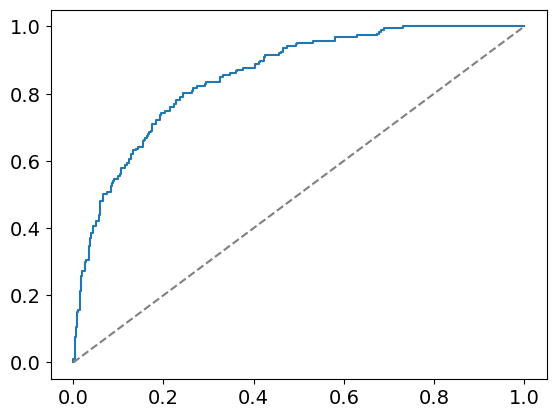

In [85]:
fpr, tpr, _ = roc_curve(y_train, lg4.predict(x_train4))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle='--', color='grey')
plt.show();

In [86]:
auc_score = roc_auc_score(y_train, lg4.predict(x_train4))
auc_score

0.8532620320855615

### Final Prediction of Test Data

In [87]:
x_test = x_test.drop(['SkinThickness','BloodPressure','Insulin','Age'], axis=1)

In [88]:
pred_test = np.round(lg4.predict(x_test)>0.5)

In [89]:
accuracy_score(y_train, pred_train4)

0.7821229050279329

In [90]:
accuracy_score(y_test, pred_test)

0.7489177489177489

### Naive Bayes Algorithm

In [96]:
data1 = df.copy()

In [97]:
data1['class'].value_counts(1)*100

class
0    65.104167
1    34.895833
Name: proportion, dtype: float64

In [99]:
nbx = data1.drop(['class'],axis=1)
nby = data1['class']
nbx_train, nbx_test, nby_train, nby_test = train_test_split(nbx, nby, test_size = 0.3, stratify = y, random_state=42)

In [100]:
diab_model = GaussianNB()
diab_model.fit(nbx_train, nby_train.ravel())

GaussianNB()

In [102]:
diab_train_predict = diab_model.predict(nbx_train)

In [103]:
print(classification_report(nby_train, diab_train_predict))

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       350
           1       0.70      0.62      0.66       187

    accuracy                           0.78       537
   macro avg       0.76      0.74      0.75       537
weighted avg       0.77      0.78      0.77       537



In [106]:
diab_test_predict = diab_model.predict(nbx_test)
print(classification_report(nby_test, diab_test_predict))

              precision    recall  f1-score   support

           0       0.80      0.81      0.81       150
           1       0.64      0.62      0.63        81

    accuracy                           0.74       231
   macro avg       0.72      0.72      0.72       231
weighted avg       0.74      0.74      0.74       231



In [110]:
nb_cm = confusion_matrix(nby_test, diab_test_predict)
custom_nb_cm = pd.DataFrame([[nb_cm[1,1],nb_cm[1,0]],
                             [nb_cm[0,1],nb_cm[0,0]]],
                            columns=['Predicted Positive','Predicted Negative'],
                            index=['Actual Positive','Actual Negative'])
custom_nb_cm

,Predicted Positive,Predicted Negative
Actual Positive,50,31
Actual Negative,28,122
